In [1]:
import torch
from model import CNN
from contrastive import ContrastiveLearning
from ebt import EBTTrainer
import omegaconf 
import matplotlib.pyplot as plt

In [2]:
conf = omegaconf.OmegaConf.load("./config.yaml")
model = EBTTrainer(CNN(conf), conf)
with open("./checkpoints/energy_based_learning.pth", "rb") as f:
    model.load_state_dict(torch.load(f, map_location="mps"))
model.to("mps")

EBTTrainer(
  (model): CNN(
    (cnn_layers): Sequential(
      (0): Conv2d(1, 16, kernel_size=(5, 5), stride=(2, 2), padding=(4, 4))
      (1): Swish()
      (2): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (3): Swish()
      (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (5): Swish()
      (6): Conv2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (7): Swish()
      (8): Flatten(start_dim=1, end_dim=-1)
      (9): Linear(in_features=256, out_features=64, bias=True)
      (10): Swish()
      (11): Linear(in_features=64, out_features=1, bias=True)
    )
    (mse_loss): MSELoss()
  )
)

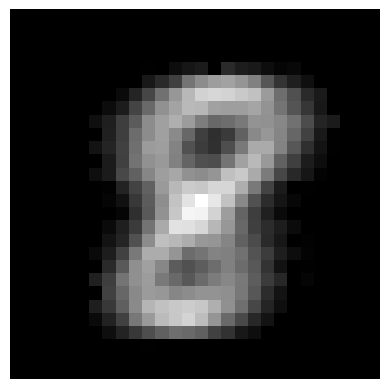

In [33]:
sv = model.sample_langevin(
    num_samples=1,
    steps=200,
    step_size=10,
    noise_scale=0.005
) 
# sv is [16, 1, 28, 28]

img = sv[0].cpu().detach().squeeze() 
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.show()

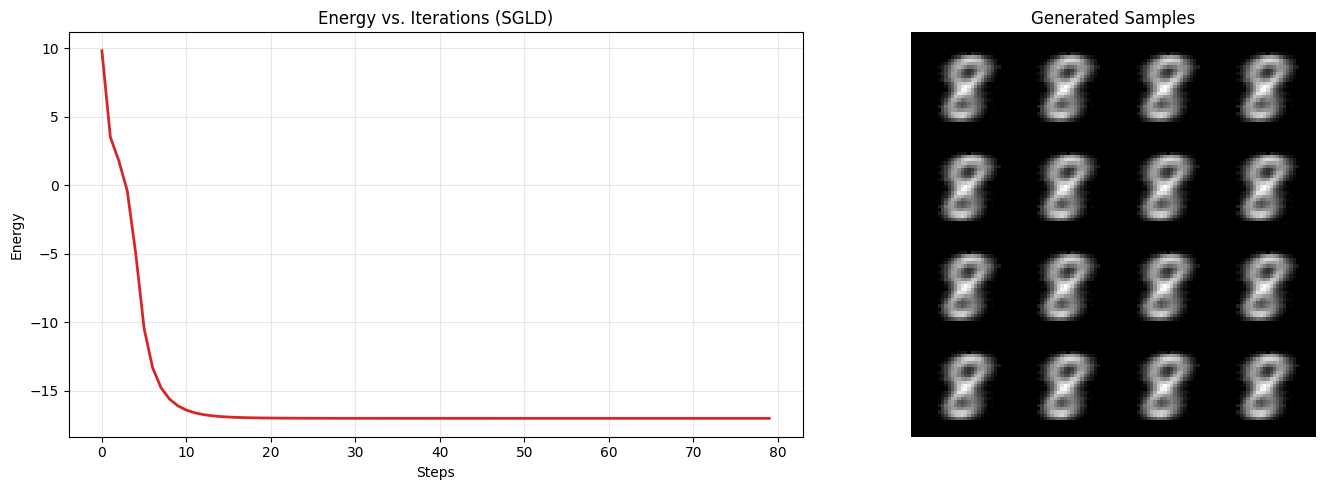

In [6]:
import torchvision
def plot_results(samples, energy_history):
    """
    Displays the energy convergence and the final sampled images.
    """
    fig, ax = plt.subplots(1, 2, figsize=(15, 5))
    
    # Plot Energy Curve
    ax[0].plot(energy_history, color='tab:red', linewidth=2)
    ax[0].set_title("Energy vs. Iterations (SGLD)")
    ax[0].set_xlabel("Steps")
    ax[0].set_ylabel("Energy")
    ax[0].grid(True, alpha=0.3)
    
    # Plot Image Grid
    ax[1].set_title("Generated Samples")
    # Rescale from [-1, 1] to [0, 1] for visualization
    grid_img = torchvision.utils.make_grid(samples, nrow=4, normalize=True, padding=2)
    img_np = grid_img.permute(1, 2, 0).cpu().numpy()
    ax[1].imshow(img_np)
    ax[1].axis('off')
    
    plt.tight_layout()
    plt.show()

# Example Usage:
# samples, energies = my_model.sample_with_energy_track(steps=60, step_size=10, noise_scale=0.005)
# plot_results(samples, energies)

samples, energies = model.sample_langevin(
    num_samples=16,
    steps=80,
    step_size=10,
    noise_scale=0.00,
    record_energy=True
)
plot_results(samples, energies)